# 01 — EDA почасового спроса Citi Bike

**Данные:** `data/processed/hourly_demand.parquet` (2023–2024).  
**Цель:** сезонность по часам, влияние осадков, подготовка к feature engineering.  
**Выводы:** выраженные суточные пики; спрос ниже в дождь; рост уровня 2023→2024.

In [ ]:
# EDA
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_parquet(Path("../data/processed/hourly_demand.parquet"))
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(df.shape)
df.head()


(17544, 9)


,timestamp,trip_count,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weather_code,wind_speed_10m
0,2023-01-01 00:00:00-05:00,1059,10.9,99.0,1.0,1.0,0.0,55.0,11.3
1,2023-01-01 01:00:00-05:00,1696,10.6,99.0,1.0,1.0,0.0,55.0,7.4
2,2023-01-01 02:00:00-05:00,1629,10.6,98.0,0.1,0.1,0.0,51.0,13.1
3,2023-01-01 03:00:00-05:00,1056,10.4,96.0,0.0,0.0,0.0,0.0,16.0
4,2023-01-01 04:00:00-05:00,619,9.8,95.0,0.0,0.0,0.0,0.0,16.0


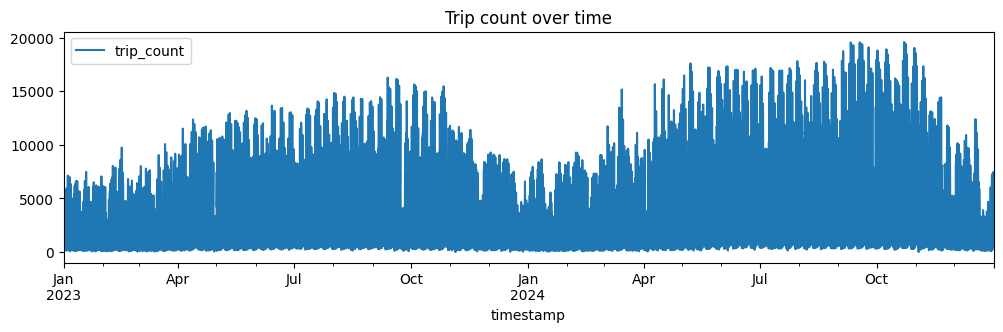

In [ ]:
df.plot(x="timestamp", y="trip_count", figsize=(12, 3))
plt.title("Trip count over time")
plt.show()


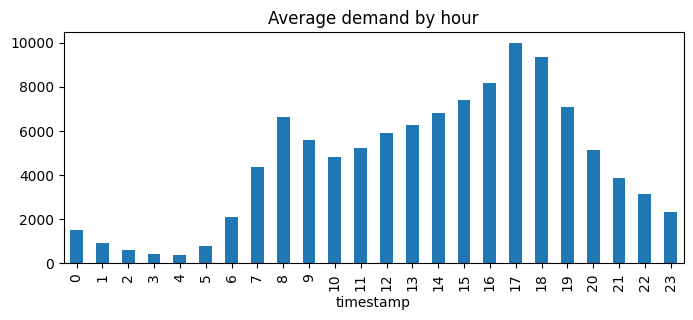

In [ ]:
df.groupby(df["timestamp"].dt.hour)["trip_count"].mean().plot(kind="bar", figsize=(8, 3))
plt.title("Average demand by hour")
plt.show()


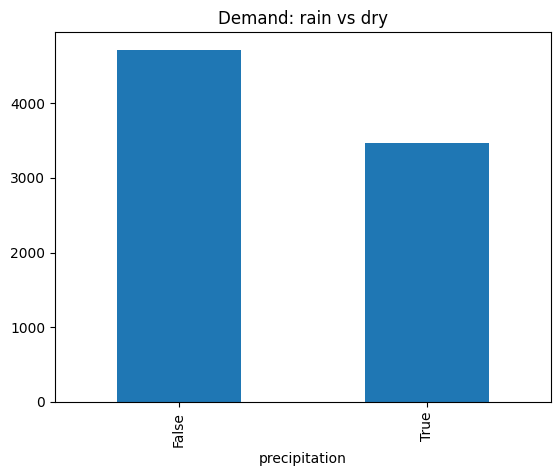

In [ ]:
rain = df["precipitation"] > 0
df.groupby(rain)["trip_count"].mean().plot(kind="bar")
plt.title("Demand: rain vs dry")
plt.show()
